## 5.8-1 F-16 Long Dynamics

In [59]:
import sys
sys.path.append('../')
import control as ct
import numpy as np
from scipy.optimize import brentq
from modeling.eqm import airdata
from modeling.params_f16 import Controls, F16Params
from tools.lin_f16 import get_lin_f16

TARGET_QBAR_PSf = 300.0
params = F16Params()
params.VT_ftps = 502.0
params.xcg = 0.35
params.alt_ft = 0.0

lon_sys, _ = get_lin_f16(Controls(), params)
state_indices = [lon_sys.nstates.index("VT_fps"), lon_sys.nstates.index("alpha_rad"), lon_sys.nstates.index("theta_rad"), lon_sys.nstates.index("q_rps")]
output_indices = [lon_sys.noutputs.index("VT_fps"), lon_sys.noutputs.index("q_dps"),lon_sys.noutputs.index("nz_g_pilot")]
elevator_index = [lon_sys.ninputs.index("elev_deg")]

A = lon_sys.A[state_indices][:, state_indices]
# override A to match book
A = np.array([[-0.1270, -235.0000, -32.2000, -9.5100, -0.2440],
              [0,       -0.9690,    0,        0.9080, -0.0020],
              [0,        0,         0,        1,       0],
              [0,       -4.5600,    0,       -1.5800,  -0.2000],
              [0,        0,         0,        0,      -20.2]])
B = lon_sys.B[state_indices][:, elevator_index]
# override B to match book
B = np.array([[0], [0], [0], [0], [20.2]])
C = lon_sys.C[output_indices][:,state_indices]
D = lon_sys.D[output_indices][:,elevator_index]
C = np.append(C,D,axis=1)

reduced_sys = ct.ss(A, B, C, 0)
reduced_sys

Trim results:
Throttle (0-1): 0.26
Elevator (deg): -0.76
Alpha (deg): 2.12
Aileron (deg): 0.00
Rudder (deg): -0.00
Beta (deg): -0.00


<LinearIOSystem:sys[134]:['u[0]']->['y[0]', 'y[1]', 'y[2]']>

#### Choose control variable
$$
    y(t) = n_{zp}
$$

#### Find zero dynamics
$$
    A_z = [I - B(CB)^{-1}C]A
$$

In [82]:
C = reduced_sys.C[-1,:].reshape(1,-1)
Az = (np.eye(reduced_sys.A.shape[0]) - reduced_sys.B @ np.linalg.inv(C @ reduced_sys.B) @ C) @ reduced_sys.A
D, V = np.linalg.eig(Az)
D

array([-3.66391722e+00+7.62430101j, -3.66391722e+00-7.62430101j,
       -1.24419588e-01+0.j        ,  5.48009172e-02+0.j        ,
       -6.85283348e-16+0.j        ])

#### Choose control variable
$$
    y(t) = C^* = n_{zp} + 12.4q
$$

In [83]:
C = reduced_sys.C[-1,:].reshape(1,-1) + 12.4 * reduced_sys.C[1,:].reshape(1,-1) / 57.3
Az = (np.eye(reduced_sys.A.shape[0]) - reduced_sys.B @ np.linalg.inv(C @ reduced_sys.B) @ C) @ reduced_sys.A
D, V = np.linalg.eig(Az)
D

array([-5.62670470e+01, -2.13837578e+00, -1.25158861e-01,  3.23975598e-02,
       -5.49991106e-16])

#### Adjust control variable
$$
    y(t) = C^* - 0.014V_T
$$

In [84]:
A = reduced_sys.A
B = reduced_sys.B
C = reduced_sys.C
C = C[-1,:].reshape(1,-1) + 12.4 * C[1,:].reshape(1,-1) / 57.3 - 0.014 * C[0,:].reshape(1,-1)
Az = (np.eye(A.shape[0]) - B @ np.linalg.inv(C @ B) @ C) @ A
D, V = np.linalg.eig(Az)
D

array([-5.61891618e+01, -2.02028609e+00, -1.42390759e-01, -7.59531357e-02,
       -3.71378138e-16])

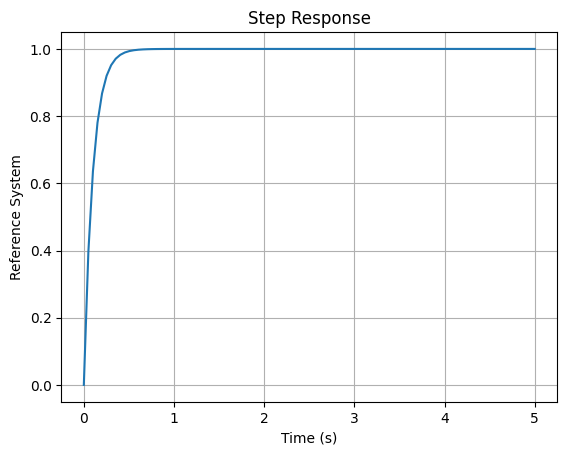

In [85]:
K = 10
sys_ref = ct.ss(-K,K,1,0)

import matplotlib.pyplot as plt
plt.figure()
t = np.linspace(0,5,100)
t,yr = ct.step_response(sys_ref,t)
plt.plot(t, yr.T)
plt.xlabel('Time (s)')
plt.ylabel('Reference System')
plt.title('Step Response')
plt.grid()
plt.show()

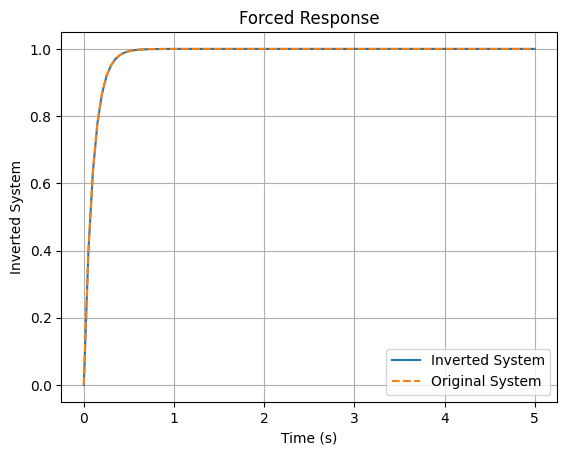

In [104]:
sys_inv = ct.ss(Az - B @ np.linalg.inv(C @ B) * K @ C, B @ np.linalg.inv(C @ B), C, 0)
t, y_inv = ct.forced_response(sys_inv, t, np.ones(t.shape))
plt.figure()
plt.plot(t, K * y_inv.T, label='Inverted System')
plt.plot(t, yr, label='Original System', linestyle='--')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Inverted System')
plt.title('Forced Response')
plt.grid()
plt.show()

## 5.8-2 Nonlinear Dynamic Inversion